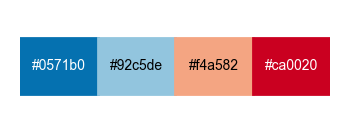

In [7]:
import matplotlib.pyplot as plt

colors = ['#0571b0', '#92c5de', '#f4a582', '#ca0020']
labels = ['#0571b0', '#92c5de', '#f4a582', '#ca0020']

fig, ax = plt.subplots(figsize=(2, 0.6), dpi=200)

for i, (c, lab) in enumerate(zip(colors, labels)):
    # 画色块
    ax.add_patch(plt.Rectangle((i, 0.2), 1, 0.6, color=c))
    
    # 写标签（在色块中间）
    ax.text(i + 0.5, 0.5, lab,
            ha='center', va='center',
            fontsize=5,
            color='white' if i in [0, 3] else 'black')  # 深色用白字更清晰

ax.set_xlim(0, len(colors))
ax.set_ylim(0, 1)
ax.axis('off')

plt.show()

In [8]:
import pandas as pd
import os
import shutil
import subprocess
from tqdm import tqdm
import json
from ast import literal_eval
import re
import requests
from Bio import pairwise2
import pickle

# input and output

In [9]:
ref3_experiment_result_file = '../../Data/Drug/drug_metabolite_Wu_2025.xlsx'
ref3_retro_result_filter_file = '../../Result/ref3_drug_deg_result_filter.csv'

In [10]:
ref3_experiment_result = pd.read_excel(ref3_experiment_result_file,sheet_name='Sheet1')
ref3_experiment_result = ref3_experiment_result[ref3_experiment_result['Drug consumed (%)']!='Not applicable']
deg_success_drug_list = set(ref3_experiment_result[ref3_experiment_result['Drug consumed (%)'].apply(lambda x:x>50)]['Drug Name'].to_list())
deg_fail_drug_list = set(ref3_experiment_result[ref3_experiment_result['Drug consumed (%)'].apply(lambda x:x<50)]['Drug Name'].to_list())

In [11]:
ref3_retro_result = pd.read_csv(ref3_retro_result_filter_file)

list1 = ref3_retro_result[ref3_retro_result['drug_name'].isin(deg_success_drug_list)]['reaction_num'].to_list()
list2 = ref3_retro_result[ref3_retro_result['drug_name'].isin(deg_fail_drug_list)]['reaction_num'].to_list()

p-value: 0.28299819431653017 ns


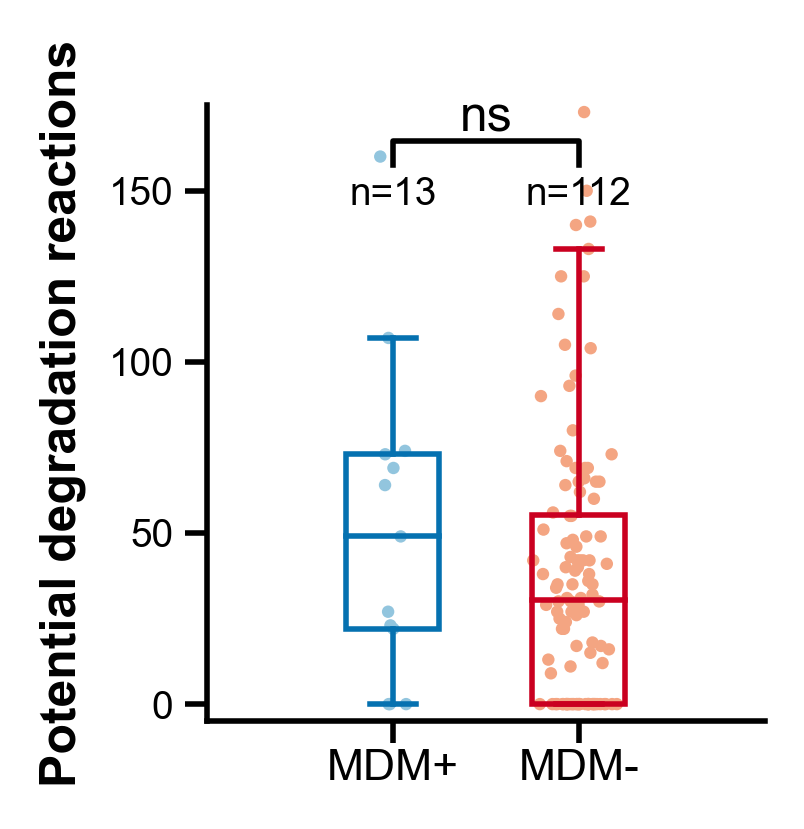

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu

# 示例数据
data1 = list1
data2 = list2
all_data = [data1, data2]

# ===== 统计检验 =====
stat, p = mannwhitneyu(data1, data2, alternative='two-sided')

def p_to_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

star = p_to_star(p)
print('p-value:', p, star)

# ===== 画图 =====
plt.figure(figsize=(1.8, 2), dpi=400)
plt.rcParams.update({'font.size': 9})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

# 坐标轴样式
plt.xticks([], fontsize=7)
plt.yticks(fontsize=7)
ax = plt.gca()
ax.spines['top'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['right'].set_linewidth(0)

# 颜色
colors = ['#0571b0', '#ca0020']

# 箱线图
positions = [0.5, 1.5]
box = plt.boxplot(all_data, positions=positions, widths=0.5,
                  patch_artist=True, showfliers=False)

# 箱体
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor('none')
    patch.set_edgecolor(color)
    patch.set_linewidth(1)

# whiskers
for i, (line1, line2) in enumerate(zip(box['whiskers'][::2], box['whiskers'][1::2])):
    color = colors[i]
    line1.set_color(color)
    line2.set_color(color)
    line1.set_linewidth(1)
    line2.set_linewidth(1)

# caps
for i, (line1, line2) in enumerate(zip(box['caps'][::2], box['caps'][1::2])):
    color = colors[i]
    line1.set_color(color)
    line2.set_color(color)
    line1.set_linewidth(1)
    line2.set_linewidth(1)

# median
for median, color in zip(box['medians'], colors):
    median.set_color(color)
    median.set_linewidth(1)

# scatter
group_colors = ['#92c5de', '#f4a582']
for i, group in enumerate(all_data):
    x_jittered = positions[i] + np.random.normal(0, 0.08, size=len(group))
    plt.scatter(x_jittered, group,
                color=group_colors[i],
                edgecolors='none',
                s=5,
                zorder=-3,
                alpha=1)

# ===== 显著性标注 =====
x1, x2 = positions
y_max = 140
h = (y_max) * 0.05 if y_max > 0 else 1  # 自适应高度
y = y_max + h

# 横线
plt.plot([x1, x1, x2, x2],
         [y+h+0.5*h, y+h+h+0.5*h, y+h+h+0.5*h, y+h+0.5*h],
         lw=1, c='black', zorder=3)

# 星号
plt.text((x1 + x2) / 2, y + h +h+0.5*h,
         star,
         ha='center', va='bottom',
         fontsize=9, zorder=3)

# ===== 标注 N（在箱子上方）=====
n1 = len(data1)
n2 = len(data2)

h = y_max * 0.05 if y_max > 0 else 1

plt.text(positions[0], y_max + h*0.5, f'n={n1}',
         ha='center', va='bottom', fontsize=7)

plt.text(positions[1], y_max + h*0.5, f'n={n2}',
         ha='center', va='bottom', fontsize=7)

# 坐标轴
plt.xlim(-0.5, 2.5)
plt.ylim(-5, y_max + 5*h)
plt.xticks(positions, ['MDM+', 'MDM-'], fontsize=8)
plt.ylabel('Potential degradation reactions', fontsize=9, fontweight='bold')

plt.tick_params(axis='y', direction='out', width=1, which='both', length=4, pad=2)
plt.tick_params(axis='x', direction='out', width=1, which='both', length=4, pad=1)


plt.savefig('../../Figure/Figure-S3b.pdf', dpi=400, bbox_inches='tight')
plt.show()